In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
file_path = "../../dataset/prepared/final_preprocessed_8PCs.csv"
df = pd.read_csv(file_path)

# Optional: Preview the first few rows
df.head()


,FP_IDX,FP_AMP1,FP_AMP2,CIR_PWR,MAX_NOISE,RXPACC,PREAM_LEN,CIR_PC1,CIR_PC2,CIR_PC3,CIR_PC4,CIR_PC5,CIR_PC6,CIR_PC7,CIR_PC8,RANGE
0,745.0,18712.0,10250.0,11855.0,967.0,611.0,1024.0,-10.899240,21.536682,-1.663086,-9.069089,-6.491534,-2.442977,-6.911036,-8.475677,3.90
1,749.0,11239.0,6313.0,18968.0,1133.0,447.0,1024.0,28.390261,-54.587130,-34.088007,-11.310028,-6.324734,-2.996781,2.770749,-1.643189,0.66
2,746.0,17845.0,18095.0,11380.0,1744.0,276.0,1024.0,55.250058,56.398613,22.352259,-9.362803,-8.034061,-17.334001,-0.793633,23.452083,1.19
3,748.0,18991.0,19444.0,13006.0,3904.0,283.0,1024.0,80.200057,13.423382,40.347520,-19.820667,7.579159,-11.896430,-12.592022,-1.772267,0.28
4,744.0,14781.0,10399.0,8025.0,1035.0,272.0,1024.0,20.229733,58.397655,-40.727859,16.409829,-12.187324,2.244173,-3.831716,16.710905,1.23


In [29]:
X = df.drop(columns=["RANGE"])
y = df["RANGE"]


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=111)

Linear Regression Performance on Test Set:
Mean Absolute Error: 0.8960749183539303
Mean Squared Error: 1.3181932499097324
R-squared: 0.5210355274662717


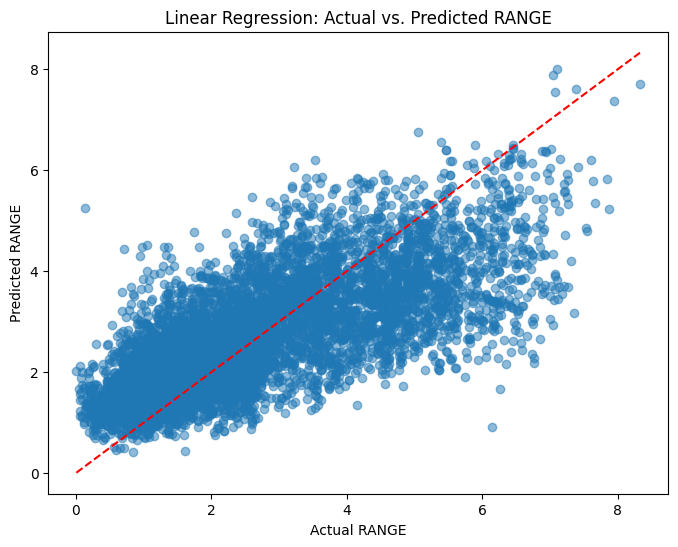

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# Create and train the Linear Regression model
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Predict on the test set
y_pred = linreg.predict(X_test)

# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance on Test Set:")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")

# Plot Actual vs. Predicted values
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual RANGE")
plt.ylabel("Predicted RANGE")
plt.title("Linear Regression: Actual vs. Predicted RANGE")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


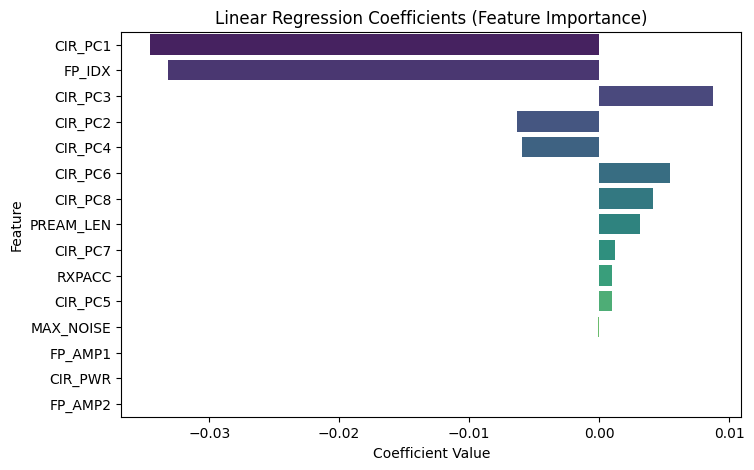

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming 'linreg' is your trained LinearRegression model
# and that X_train is your feature matrix with the target column removed.
# If you haven't dropped "RANGE" from X, consider doing so for this analysis.
# For example:
# X_train_no_range = X_train.drop(columns=["RANGE"])
# Otherwise, if X_train already excludes RANGE, then:
X_train_no_range = X_train  # Ensure that target "RANGE" is not in X_train

# Extract coefficients from the linear regression model
coefficients = pd.Series(linreg.coef_, index=X_train_no_range.columns)
# Sort coefficients by absolute value (largest impact first)
coefficients_sorted = coefficients.reindex(coefficients.abs().sort_values(ascending=False).index)

plt.figure(figsize=(8,5))
ax = sns.barplot(x=coefficients_sorted.values,
                 y=coefficients_sorted.index,
                 hue=coefficients_sorted.index,
                 palette="viridis",
                 dodge=False)
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Linear Regression Coefficients (Feature Importance)")
plt.show()


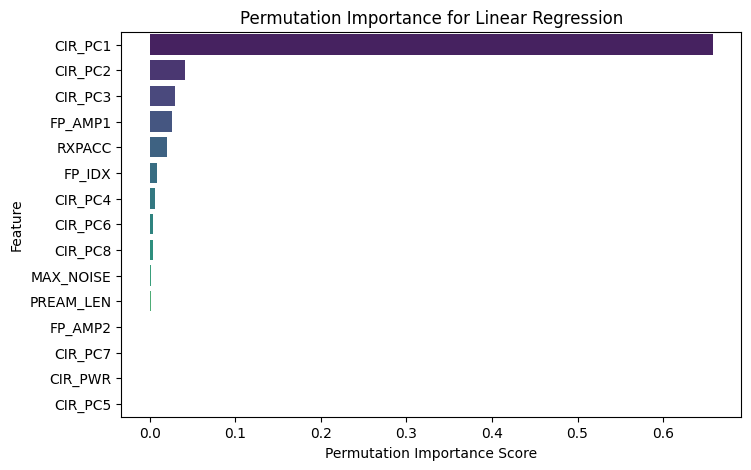

In [33]:
from sklearn.inspection import permutation_importance
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate permutation importance on the test set
# (Make sure your X_test doesn't include the target column "RANGE" if needed)
X_test_no_range = X_test  # Ensure "RANGE" is dropped if necessary

r = permutation_importance(linreg, X_test_no_range, y_test, n_repeats=10, random_state=111)
perm_importances = pd.Series(r.importances_mean, index=X_test_no_range.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
ax = sns.barplot(x=perm_importances.values, 
                 y=perm_importances.index, 
                 hue=perm_importances.index, 
                 palette="viridis", 
                 dodge=False)
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.xlabel("Permutation Importance Score")
plt.ylabel("Feature")
plt.title("Permutation Importance for Linear Regression")
plt.show()


- Based on feature importance **FP_AMP2, CIR_PC7, CIR_PWR,CIR_PC5** (for dataset final_preprocessed_8PCs.cvs)
  - Mean Absolute Error: 0.8960749183539303
  - Mean Squared Error: 1.3181932499097324
  - R-squared: 0.5210355274662717
  
- Based on feature importance, can remove **MAX_NOISE,CIR_PC5/7, RXPACC** (for dataset final_preprocessed_8PCs_both.cvs)
  - Mean Absolute Error: 1.249731593271678
  - Mean Squared Error: 2.6274648674134844
  - R-squared: 0.5281184811391348

- Based on feature importance, can remove **CIR5/7, FP_AMP2, RXPACC** (for dataset final_preprocessed_8PCs_both_all.cvs)

  - Mean Absolute Error: 1.2432953540338854
  - Mean Squared Error: 2.609175616196198
  - R-squared: 0.5314031528964157